**Сначала сделал расчёты в notebook, потом решил чуть улучшить визуализацию, чтобы графики были понятнее в отчёте:** 

добавил подписи, 

проценты, 

базовые линии, 

легенды и анонимизацию производственных значений. 

Это обычный matplotlib, просто с более аккуратным оформлением.

> Примечание 

Руководство попросило не раскрывать производствунную информацию, с преподавателем это было согласовано.

Если нужно могу предоставить от руководства письменное подтверждение актуальности данных.

Но когда буду строить модель, признаки продемонстрировать разрешили, но не типы продукта и марки стали.

In [ ]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.patches import FancyBboxPatch

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


# НАСТРОЙКИ
DATA_PATH = "input_data.csv"

TIME_COL = "Дата-время производства"

TARGET_COL_CANDIDATES = [
    "Карантины ПК | Неплоскостность | Стан 2000 | После стана",
    "Карантины_ПК | Неплоскостность_Стан 2000_После стана",
]

DOMAIN_FILTERS = [
    {
        "col": "Следующий цех (ПЗ)",
        "mode": "include",
        "value": "ЛПЦ-2",
        "public_label": "Фильтр 1\nмаршрут продукции",
    },
    {
        "col": "Конечный цех (ПЗ)",
        "mode": "include",
        "value": "ЛПЦ-2",
        "public_label": "Фильтр 2\nконечный участок",
    },
    {
        "col": "Тип продукта (СЗ)",
        "mode": "include",
        "value": "Лист г/к",
        "public_label": "Фильтр 3\nтип продукта",
    },
    {
        "col": "Внутреннее назначение ЛПЦ-2 (ПЗ)",
        "mode": "exclude",
        "value": ["ЦГП5", "ЦХП", "ЦХП650", "РШК5"],
        "public_label": "Фильтр 4\nисключения",
    },
]


# реальные значения марок стали и продуктов - скрою анонимизацией
STEEL_GRADE_COL = "Марка (СЗ)"
PRODUCT_TYPE_COL = "Тип продукта (СЗ)"

LAB_DELAY_DAYS = 14
HOLDOUT_START = pd.Timestamp("2026-04-16")

# НАСТРОЙКИ СТИЛЯ ГРАФИКОВ
COL_BLUE = "#2F80ED"
COL_DARK_BLUE = "#174EA6"
COL_RED = "#EB5757"
COL_GREEN = "#27AE60"
COL_ORANGE = "#F2994A"
COL_GRAY = "#BDBDBD"
COL_LIGHT_GRAY = "#E0E0E0"
COL_DARK = "#333333"
COL_PURPLE = "#9B51E0"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

def fmt_int(x, pos=None):
    try:
        return f"{int(x):,}".replace(",", " ")
    except Exception:
        return str(x)

def fmt_pct(x):
    return f"{x * 100:.1f}%".replace(".", ",")

def clean_str(s):
    return s.astype("string").str.replace("\xa0", " ", regex=False).str.strip()

def prettify(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

# ЗАГРУЗКА ДАННЫХ
try:
    df = pd.read_csv(DATA_PATH, low_memory=False, compression="gzip")
except Exception:
    df = pd.read_csv(DATA_PATH, low_memory=False)

print("ДАННЫЕ ЗАГРУЖЕНЫ")
print(f"shape: {df.shape[0]:,} строк x {df.shape[1]:,} колонок".replace(",", " "))

target_col = next((c for c in TARGET_COL_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise ValueError("Не найден TARGET_COL.")

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

print(f"TIME_COL  : {TIME_COL}")
print(f"TARGET_COL: {target_col}")
print(f"Период    : {df[TIME_COL].min()} — {df[TIME_COL].max()}")

ДАННЫЕ ЗАГРУЖЕНЫ
shape: 252 609 строк x 2 895 колонок
TIME_COL  : Дата-время производства
TARGET_COL: Карантины ПК | Неплоскостность | Стан 2000 | После стана
Период    : 2025-06-01 00:00:31 — 2026-04-30 23:02:56


In [2]:
# ДОМЕННЫЕ ФИЛЬТРЫ
mask = pd.Series(True, index=df.index)

funnel_labels = ["Исходный\nдатасет"]
funnel_counts = [len(df)]
funnel_retention = [1.0]

print("ДОМЕННЫЕ ФИЛЬТРЫ")

for f in DOMAIN_FILTERS:
    col = f["col"]
    
    if col not in df.columns:
        print(f"[SKIP] Нет колонки: {col}")
        continue
    
    before = int(mask.sum())
    s = clean_str(df[col])
    
    if f["mode"] == "include":
        mask &= s.eq(f["value"]).fillna(False)
    else:
        mask &= ~s.isin(f["value"]).fillna(False)
    
    after = int(mask.sum())
    retention = after / before if before else 0
    
    funnel_labels.append(f["public_label"])
    funnel_counts.append(after)
    funnel_retention.append(retention)
    
    print(f"{f['public_label'].replace(chr(10), ' ')}: {fmt_int(before)} -> {fmt_int(after)} | осталось {fmt_pct(retention)} от пред. шага")

df_work = df.loc[mask].copy()

# TARGET
y = df_work[target_col].notna().astype(int)
df_work["target"] = y

pos = int(y.sum())
neg = int((1 - y).sum())
base_rate = y.mean()

print()
print("РАБОЧАЯ ВЫБОРКА И TARGET")
print(f"Строк после фильтров : {fmt_int(len(df_work))}")
print(f"Колонок              : {fmt_int(df_work.shape[1] - 1)} без служебного target")
print(f"Позитивный класс     : {fmt_int(pos)}")
print(f"Негативный класс     : {fmt_int(neg)}")
print(f"Доля дефекта         : {fmt_pct(base_rate)}")
print(f"Логика target        : 1 если целевая колонка не пустая, иначе 0")

ДОМЕННЫЕ ФИЛЬТРЫ
Фильтр 1 маршрут продукции: 252 609 -> 135 243 | осталось 53,5% от пред. шага
Фильтр 2 конечный участок: 135 243 -> 118 401 | осталось 87,5% от пред. шага
Фильтр 3 тип продукта: 118 401 -> 26 854 | осталось 22,7% от пред. шага
Фильтр 4 исключения: 26 854 -> 26 854 | осталось 100,0% от пред. шага

РАБОЧАЯ ВЫБОРКА И TARGET
Строк после фильтров : 26 854
Колонок              : 2 895 без служебного target
Позитивный класс     : 1 892
Негативный класс     : 24 962
Доля дефекта         : 7,0%
Логика target        : 1 если целевая колонка не пустая, иначе 0


ОБЩАЯ СТРУКТУРА ДАТАСЕТА
Исходный датасет: 252 609 строк, 2 895 колонок, дней: 327
Рабочая выборка : 26 854 строк, 2 895 колонок, дней: 327


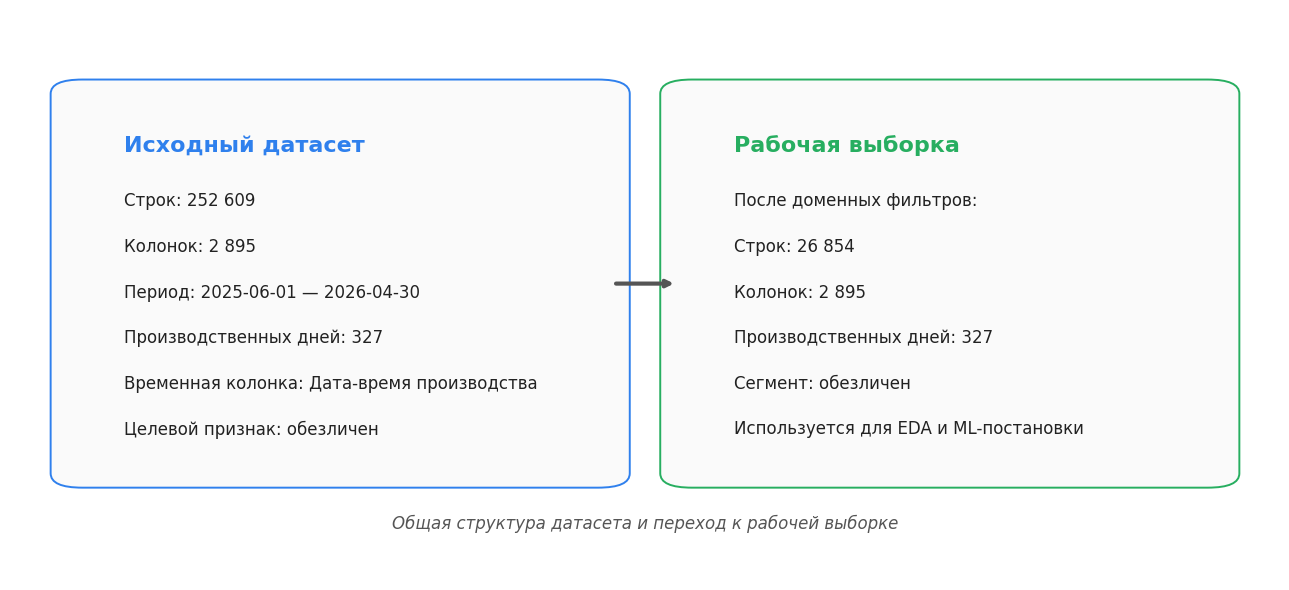

In [3]:
raw_rows = len(df)
raw_cols = df.shape[1]

date_min = df[TIME_COL].min().strftime("%Y-%m-%d")
date_max = df[TIME_COL].max().strftime("%Y-%m-%d")
raw_days = df[TIME_COL].dt.floor("D").nunique()
work_days = df_work[TIME_COL].dt.floor("D").nunique()

print("ОБЩАЯ СТРУКТУРА ДАТАСЕТА")
print(f"Исходный датасет: {fmt_int(raw_rows)} строк, {fmt_int(raw_cols)} колонок, дней: {raw_days}")
print(f"Рабочая выборка : {fmt_int(len(df_work))} строк, {fmt_int(raw_cols)} колонок, дней: {work_days}")

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("white")
ax.axis("off")

def draw_card(x, y0, w, h, title, lines, color):
    card = FancyBboxPatch(
        (x, y0), w, h,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.4,
        edgecolor=color,
        facecolor="#FAFAFA",
    )
    ax.add_patch(card)

    ax.text(
        x + 0.04, y0 + h - 0.08,
        title,
        fontsize=16,
        fontweight="bold",
        color=color,
        va="top",
    )

    yy = y0 + h - 0.18
    for line in lines:
        ax.text(
            x + 0.04, yy,
            line,
            fontsize=12,
            color="#222222",
            va="top",
        )
        yy -= 0.08

draw_card(
    0.05, 0.18, 0.42, 0.68,
    "Исходный датасет",
    [
        f"Строк: {fmt_int(raw_rows)}",
        f"Колонок: {fmt_int(raw_cols)}",
        f"Период: {date_min} — {date_max}",
        f"Производственных дней: {raw_days}",
        "Временная колонка: Дата-время производства",
        "Целевой признак: обезличен",
    ],
    COL_BLUE,
)

draw_card(
    0.53, 0.18, 0.42, 0.68,
    "Рабочая выборка",
    [
        "После доменных фильтров:",
        f"Строк: {fmt_int(len(df_work))}",
        f"Колонок: {fmt_int(raw_cols)}",
        f"Производственных дней: {work_days}",
        "Сегмент: обезличен",
        "Используется для EDA и ML-постановки",
    ],
    COL_GREEN,
)

ax.annotate(
    "",
    xy=(0.525, 0.52),
    xytext=(0.475, 0.52),
    arrowprops=dict(arrowstyle="->", lw=3, color="#555555"),
)

ax.text(
    0.5, 0.09,
    "Общая структура датасета и переход к рабочей выборке",
    ha="center",
    fontsize=12,
    color="#555555",
    style="italic",
)

plt.tight_layout()
plt.show()

БАЛАНС КЛАССОВ
Дефект     : 1 892 строк | 7,0%
Нет дефекта: 24 962 строк | 93,0%
Вывод: дефект редкий, поэтому accuracy не подходит как главная метрика.


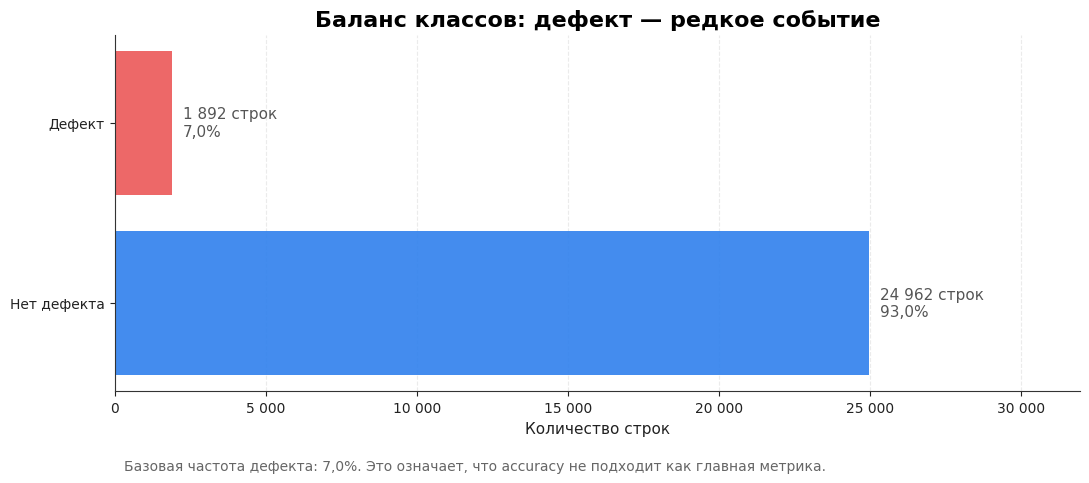

In [4]:
print("БАЛАНС КЛАССОВ")
print(f"Дефект     : {fmt_int(pos)} строк | {fmt_pct(pos / len(df_work))}")
print(f"Нет дефекта: {fmt_int(neg)} строк | {fmt_pct(neg / len(df_work))}")
print(f"Вывод: дефект редкий, поэтому accuracy не подходит как главная метрика.")

labels = ["Нет дефекта", "Дефект"]
values = [neg, pos]
colors = [COL_BLUE, COL_RED]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(labels, values, color=colors, alpha=0.9)

for bar, value in zip(bars, values):
    share = value / len(df_work)
    ax.text(
        value + max(values) * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{fmt_int(value)} строк\n{fmt_pct(share)}",
        va="center",
        fontsize=11,
        color="#555555",
    )

ax.set_title("Баланс классов: дефект — редкое событие")
ax.set_xlabel("Количество строк")
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int))
ax.set_xlim(0, max(values) * 1.28)

ax.text(
    0.01, -0.22,
    f"Базовая частота дефекта: {fmt_pct(base_rate)}. Это означает, что accuracy не подходит как главная метрика.",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

prettify(ax, grid_axis="x")
plt.tight_layout()
plt.show()

ВОРОНКА ДОМЕННЫХ ФИЛЬТРОВ
Исходный датасет: 252 609 | 100%
Фильтр 1 маршрут продукции: 135 243 | 53,5% от пред. шага
Фильтр 2 конечный участок: 118 401 | 87,5% от пред. шага
Фильтр 3 тип продукта: 26 854 | 22,7% от пред. шага
Фильтр 4 исключения: 26 854 | 100,0% от пред. шага


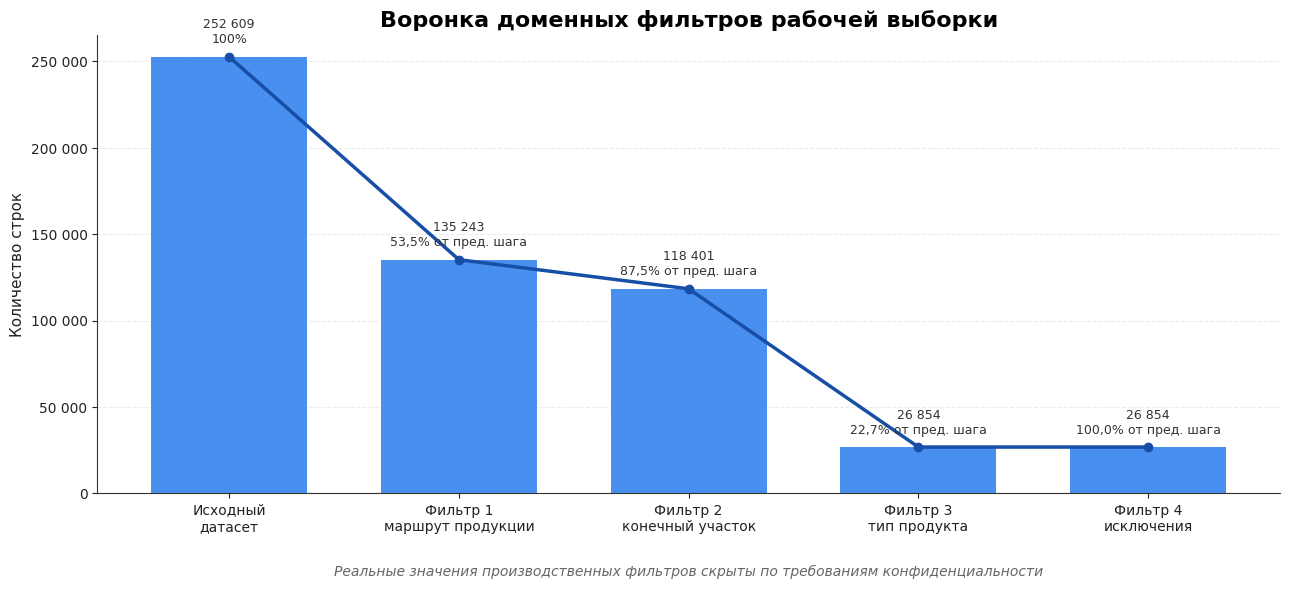

In [6]:
print("ВОРОНКА ДОМЕННЫХ ФИЛЬТРОВ")

for i, (label, count, retention) in enumerate(zip(funnel_labels, funnel_counts, funnel_retention)):
    if i == 0:
        print(f"{label.replace(chr(10), ' ')}: {fmt_int(count)} | 100%")
    else:
        print(f"{label.replace(chr(10), ' ')}: {fmt_int(count)} | {fmt_pct(retention)} от пред. шага")

fig, ax = plt.subplots(figsize=(13, 6))

x = range(len(funnel_counts))
bars = ax.bar(x, funnel_counts, color=COL_BLUE, alpha=0.88, width=0.68)

ax.plot(
    x,
    funnel_counts,
    color=COL_DARK_BLUE,
    marker="o",
    linewidth=2.5,
    markersize=6,
)

max_count = max(funnel_counts)

for i, (bar, count, retention) in enumerate(zip(bars, funnel_counts, funnel_retention)):
    if i == 0:
        txt = f"{fmt_int(count)}\n100%"
    else:
        txt = f"{fmt_int(count)}\n{fmt_pct(retention)} от пред. шага"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + max_count * 0.025,
        txt,
        ha="center",
        va="bottom",
        fontsize=9,
        color=COL_DARK,
    )

ax.set_title("Воронка доменных фильтров рабочей выборки")
ax.set_ylabel("Количество строк")
ax.set_xticks(list(x))
ax.set_xticklabels(funnel_labels)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_int))

ax.text(
    0.5, -0.18,
    "Реальные значения производственных фильтров скрыты по требованиям конфиденциальности",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#666666",
    style="italic",
)

prettify(ax, grid_axis="y")
plt.tight_layout()
plt.show()

КАЧЕСТВО ПРИЗНАКОВОГО ПРОСТРАНСТВА
Всего колонок                         : 2 895
Константные колонки                   : 2 066
Почти константные >=99%               : 2 213
Колонки с пропусками >=90%            : 2 346
Возможные ID/key колонки              : 99
Возможные post-fact/leakage по имени  : 1 930

Вывод: перед моделью нужно убрать константы, критические пропуски, ID/key и post-fact/leakage поля.


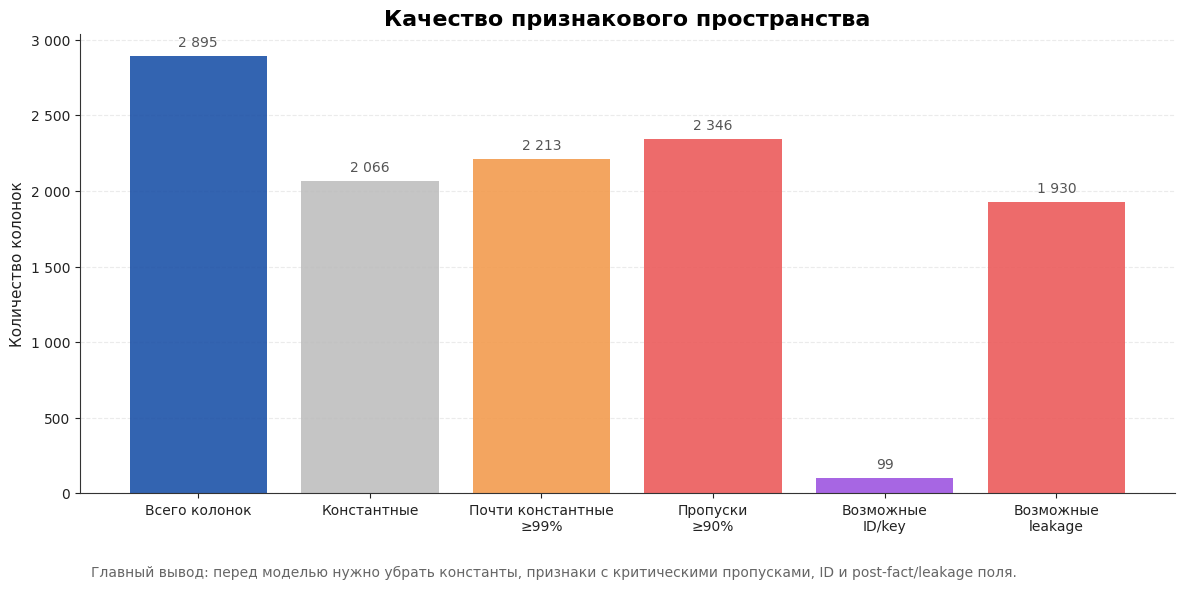

7889

In [7]:
print("КАЧЕСТВО ПРИЗНАКОВОГО ПРОСТРАНСТВА")

n_rows = len(df_work)
feature_cols = [c for c in df_work.columns if c != "target"]

missing_rate = df_work[feature_cols].isna().mean()
nunique = df_work[feature_cols].nunique(dropna=True)

constant_cols = nunique[nunique <= 1].index.tolist()

top_share = []
for c in feature_cols:
    vc = df_work[c].value_counts(dropna=False, normalize=True)
    top_share.append(vc.iloc[0] if len(vc) else np.nan)

top_share = pd.Series(top_share, index=feature_cols)

quasi_constant_cols = top_share[top_share >= 0.99].index.tolist()
high_missing_cols = missing_rate[missing_rate >= 0.90].index.tolist()

id_patterns = ["id", "ид", "номер", "рулон", "лист", "плавк", "заказ", "парт", "coil", "heat", "order", "product", "продукт"]
leak_patterns = ["карантин", "дефект", "брак", "решение", "факт", "результат", "лаборатор", "испыт", "качество", "после", "target", "label", "score", "prediction"]

possible_id_cols = [c for c in feature_cols if any(p in str(c).lower() for p in id_patterns)]
possible_leakage_cols = [c for c in feature_cols if any(p in str(c).lower() for p in leak_patterns)]

print(f"Всего колонок                         : {fmt_int(len(feature_cols))}")
print(f"Константные колонки                   : {fmt_int(len(constant_cols))}")
print(f"Почти константные >=99%               : {fmt_int(len(quasi_constant_cols))}")
print(f"Колонки с пропусками >=90%            : {fmt_int(len(high_missing_cols))}")
print(f"Возможные ID/key колонки              : {fmt_int(len(possible_id_cols))}")
print(f"Возможные post-fact/leakage по имени  : {fmt_int(len(possible_leakage_cols))}")
print()
print("Вывод: перед моделью нужно убрать константы, критические пропуски, ID/key и post-fact/leakage поля.")

labels = [
    "Всего колонок",
    "Константные",
    "Почти константные\n≥99%",
    "Пропуски\n≥90%",
    "Возможные\nID/key",
    "Возможные\nleakage",
]

values = [
    len(feature_cols),
    len(constant_cols),
    len(quasi_constant_cols),
    len(high_missing_cols),
    len(possible_id_cols),
    len(possible_leakage_cols),
]

colors = [
    COL_DARK_BLUE,
    COL_GRAY,
    COL_ORANGE,
    COL_RED,
    COL_PURPLE,
    COL_RED,
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(labels, values, color=colors, alpha=0.88)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(values) * 0.015,
        fmt_int(value),
        ha="center",
        va="bottom",
        fontsize=10,
        color="#555555",
    )

ax.set_title("Качество признакового пространства")
ax.set_ylabel("Количество колонок")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_int))

ax.text(
    0.01, -0.18,
    "Главный вывод: перед моделью нужно убрать константы, признаки с критическими пропусками, ID и post-fact/leakage поля.",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

prettify(ax, grid_axis="y")
plt.tight_layout()
plt.show()

gc.collect()

ДИНАМИКА ПО ДНЯМ
Производственных дней      : 327
Средний объём строк в день : 82.1
Средняя доля дефекта       : 7,0%
Мин. дневная доля дефекта  : 0,0%
Макс. дневная доля дефекта : 33,3%
Вывод: доля дефекта нестабильна по дням, поэтому важно смотреть не только строки, но и дневную агрегацию.


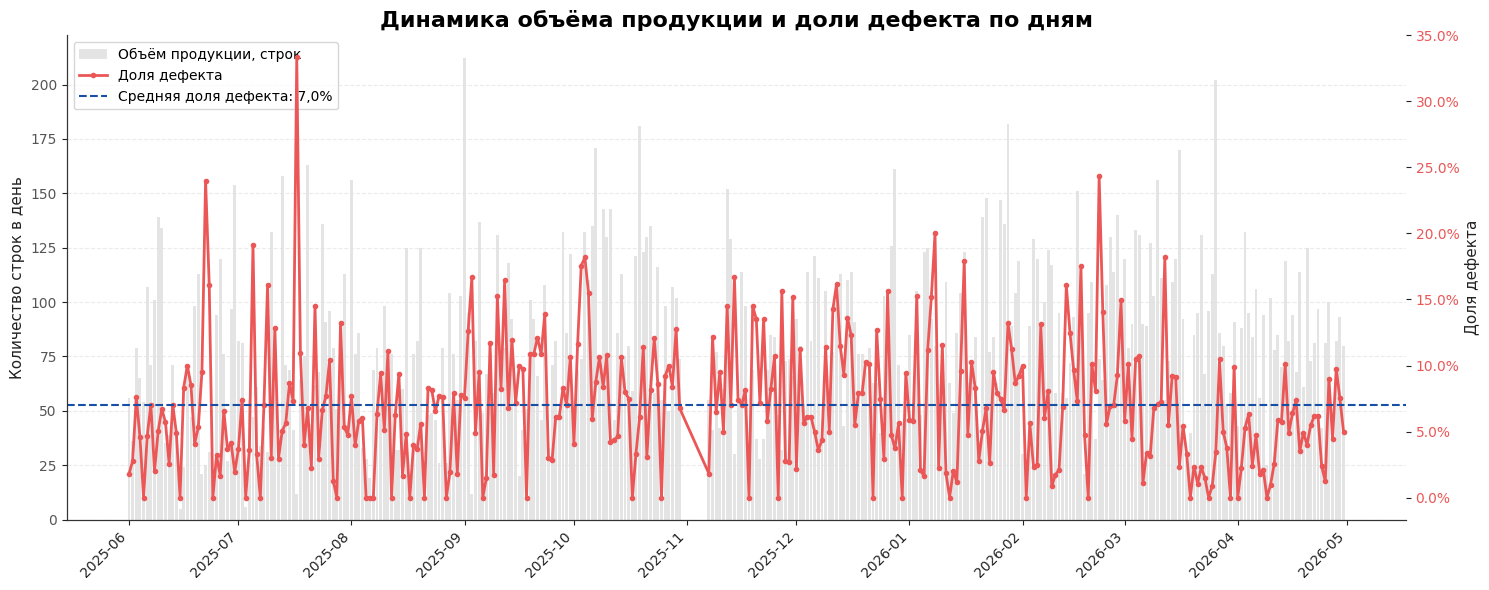

In [8]:
daily = (
    df_work
    .dropna(subset=[TIME_COL])
    .assign(day=lambda x: x[TIME_COL].dt.floor("D"))
    .groupby("day", as_index=False)
    .agg(
        n_rows=("target", "size"),
        positives=("target", "sum"),
        positive_rate=("target", "mean"),
    )
)

print("ДИНАМИКА ПО ДНЯМ")
print(f"Производственных дней      : {daily['day'].nunique()}")
print(f"Средний объём строк в день : {daily['n_rows'].mean():.1f}")
print(f"Средняя доля дефекта       : {fmt_pct(base_rate)}")
print(f"Мин. дневная доля дефекта  : {fmt_pct(daily['positive_rate'].min())}")
print(f"Макс. дневная доля дефекта : {fmt_pct(daily['positive_rate'].max())}")
print("Вывод: доля дефекта нестабильна по дням, поэтому важно смотреть не только строки, но и дневную агрегацию.")

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.bar(
    daily["day"],
    daily["n_rows"],
    color=COL_LIGHT_GRAY,
    alpha=0.85,
    label="Объём продукции, строк",
)

ax1.set_ylabel("Количество строк в день")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_int))
ax1.tick_params(axis="y", labelcolor="#555555")

ax2 = ax1.twinx()

ax2.plot(
    daily["day"],
    daily["positive_rate"],
    color=COL_RED,
    linewidth=2.0,
    marker="o",
    markersize=3,
    label="Доля дефекта",
)

ax2.axhline(
    base_rate,
    color=COL_DARK_BLUE,
    linestyle="--",
    linewidth=1.5,
    label=f"Средняя доля дефекта: {fmt_pct(base_rate)}",
)

ax2.set_ylabel("Доля дефекта")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.tick_params(axis="y", labelcolor=COL_RED)

ax1.set_title("Динамика объёма продукции и доли дефекта по дням")

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

prettify(ax1, grid_axis="y")
for side in ["top", "right"]:
    ax2.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

ЗРЕЛОСТЬ TARGET И СТАБИЛЬНОСТЬ ДОЛИ ДЕФЕКТА
Последняя дата в данных             : 2026-04-30 22:19:51
Задержка лабораторного факта        : 14 дней
Граница зрелости target             : 2026-04-16 22:19:51
Потенциально незрелых строк         : 1 146
Вывод: последние дни нужно проверять отдельно, потому что лабораторный факт может появляться с задержкой.


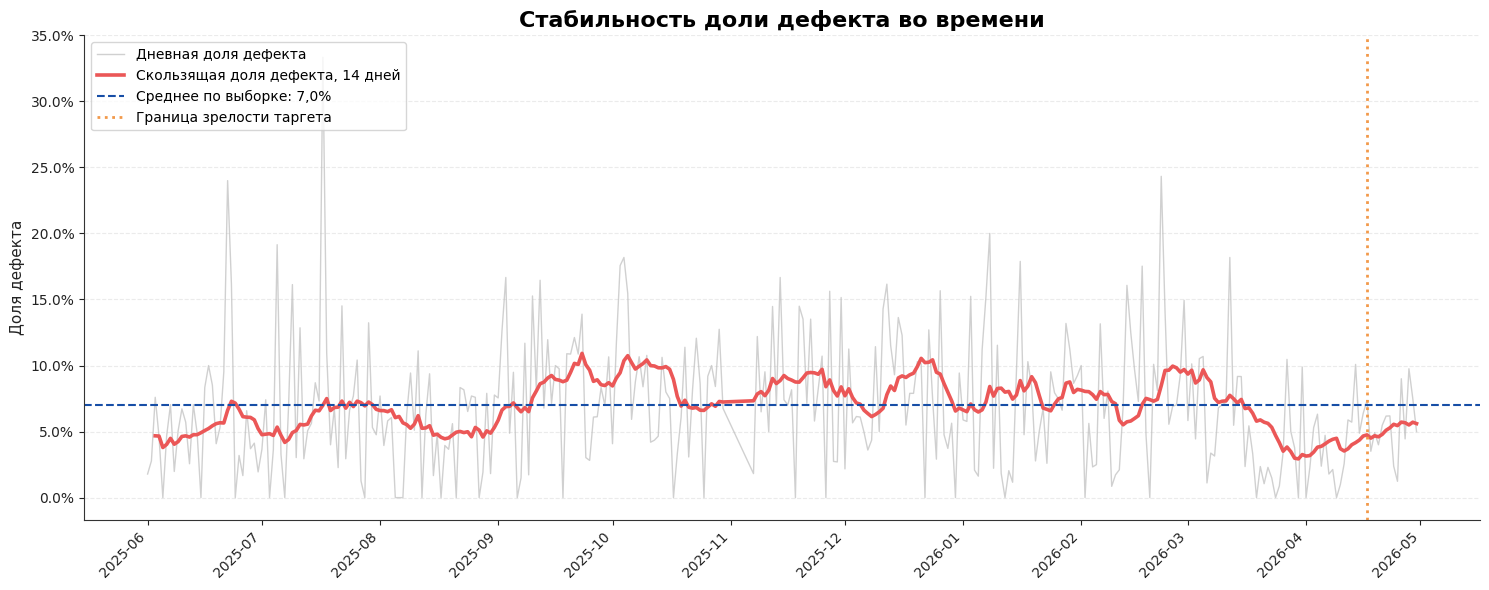

In [9]:
window = 14

daily["roll_pos"] = daily["positives"].rolling(window, min_periods=3).sum()
daily["roll_n"] = daily["n_rows"].rolling(window, min_periods=3).sum()
daily["roll_rate"] = daily["roll_pos"] / daily["roll_n"]

max_date = df_work[TIME_COL].max()
maturity_cutoff = max_date - pd.Timedelta(days=LAB_DELAY_DAYS)
immature_rows = int((df_work[TIME_COL] > maturity_cutoff).sum())

print("ЗРЕЛОСТЬ TARGET И СТАБИЛЬНОСТЬ ДОЛИ ДЕФЕКТА")
print(f"Последняя дата в данных             : {max_date}")
print(f"Задержка лабораторного факта        : {LAB_DELAY_DAYS} дней")
print(f"Граница зрелости target             : {maturity_cutoff}")
print(f"Потенциально незрелых строк         : {fmt_int(immature_rows)}")
print("Вывод: последние дни нужно проверять отдельно, потому что лабораторный факт может появляться с задержкой.")

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    daily["day"],
    daily["positive_rate"],
    color=COL_GRAY,
    linewidth=1.0,
    alpha=0.7,
    label="Дневная доля дефекта",
)

ax.plot(
    daily["day"],
    daily["roll_rate"],
    color=COL_RED,
    linewidth=2.6,
    label=f"Скользящая доля дефекта, {window} дней",
)

ax.axhline(
    base_rate,
    color=COL_DARK_BLUE,
    linestyle="--",
    linewidth=1.5,
    label=f"Среднее по выборке: {fmt_pct(base_rate)}",
)

ax.axvline(
    maturity_cutoff,
    color=COL_ORANGE,
    linestyle=":",
    linewidth=2,
    label="Граница зрелости таргета",
)

ax.set_title("Стабильность доли дефекта во времени")
ax.set_ylabel("Доля дефекта")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend(loc="upper left")
prettify(ax, grid_axis="y")

plt.tight_layout()
plt.show()

ВРЕМЕННОЕ РАЗБИЕНИЕ ВЫБОРКИ


,split,n_rows,positives,positive_rate,date_min,date_max
2,train,15424,1148,0.074429,2025-06-01 02:29:15,2025-12-26 17:44:39
3,validation,3085,230,0.074554,2025-12-26 17:46:51,2026-01-28 22:48:25
1,pretest,2057,150,0.072922,2026-01-28 22:49:59,2026-02-21 20:00:32
0,holdout,5142,300,0.058343,2026-02-21 20:03:22,2026-04-16 22:18:51



Вывод: split сделан по времени, чтобы модель проверялась на будущих данных, а не на случайном перемешивании.
Holdout оставлен как финальная имитация будущего периода.


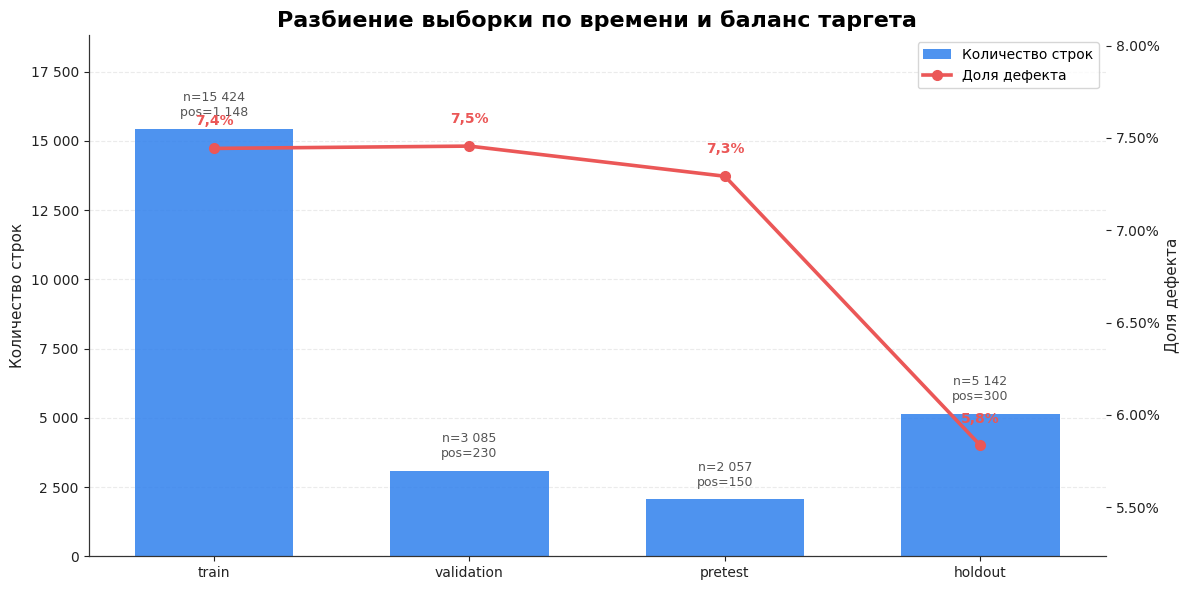

In [10]:
df_work = df_work.sort_values(TIME_COL, kind="mergesort").copy()

# Последние потенциально незрелые строки можно убрать из split-анализа
df_mature = df_work[df_work[TIME_COL] <= maturity_cutoff].copy()

n = len(df_mature)

train_end = int(n * 0.60)
val_end = int(n * 0.72)
pretest_end = int(n * 0.80)

df_mature["split"] = "holdout"
df_mature.iloc[:train_end, df_mature.columns.get_loc("split")] = "train"
df_mature.iloc[train_end:val_end, df_mature.columns.get_loc("split")] = "validation"
df_mature.iloc[val_end:pretest_end, df_mature.columns.get_loc("split")] = "pretest"

split_summary = (
    df_mature
    .groupby("split", as_index=False)
    .agg(
        n_rows=("target", "size"),
        positives=("target", "sum"),
        positive_rate=("target", "mean"),
        date_min=(TIME_COL, "min"),
        date_max=(TIME_COL, "max"),
    )
)

order = ["train", "validation", "pretest", "holdout"]
split_summary["_order"] = split_summary["split"].map({x: i for i, x in enumerate(order)})
split_summary = split_summary.sort_values("_order").drop(columns="_order")

print("ВРЕМЕННОЕ РАЗБИЕНИЕ ВЫБОРКИ")
display(split_summary)

print()
print("Вывод: split сделан по времени, чтобы модель проверялась на будущих данных, а не на случайном перемешивании.")
print("Holdout оставлен как финальная имитация будущего периода.")

fig, ax1 = plt.subplots(figsize=(12, 6))

labels = split_summary["split"].tolist()
x = np.arange(len(labels))

n_rows = split_summary["n_rows"].astype(float).values
positives = split_summary["positives"].astype(int).values
rates = split_summary["positive_rate"].astype(float).values

bars = ax1.bar(
    x,
    n_rows,
    color=COL_BLUE,
    alpha=0.85,
    width=0.62,
    label="Количество строк",
)

max_n = n_rows.max()

for bar, n_value, pos_value in zip(bars, n_rows, positives):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        n_value + max_n * 0.025,
        f"n={fmt_int(n_value)}\npos={fmt_int(pos_value)}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555555",
    )

ax1.set_ylabel("Количество строк")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_int))
ax1.set_ylim(0, max_n * 1.22)

ax2 = ax1.twinx()

ax2.plot(
    x,
    rates,
    color=COL_RED,
    marker="o",
    markersize=7,
    linewidth=2.6,
    label="Доля дефекта",
)

rate_min = rates.min()
rate_max = rates.max()
rate_pad = max((rate_max - rate_min) * 0.35, 0.006)

ax2.set_ylim(
    max(0, rate_min - rate_pad),
    min(1, rate_max + rate_pad),
)

for xi, r in zip(x, rates):
    ax2.text(
        xi,
        r + rate_pad * 0.18,
        fmt_pct(r),
        ha="center",
        va="bottom",
        fontsize=10,
        color=COL_RED,
        fontweight="bold",
    )

ax2.set_ylabel("Доля дефекта")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax1.set_title("Разбиение выборки по времени и баланс таргета")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

prettify(ax1, grid_axis="y")
for side in ["top", "right"]:
    ax2.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

ДОЛЯ ПОЗИТИВНОГО КЛАССА ПО МАРКАМ СТАЛИ


,anon_name,n_rows,positive_count,positive_rate
0,Марка 1,13296,1001,0.075286
1,Марка 2,6579,587,0.089223
2,Марка 3,1114,78,0.070018
3,Марка 4,926,32,0.034557
4,Марка 5,706,50,0.070822
5,Марка 6,395,12,0.030380
6,Марка 7,384,11,0.028646
7,Марка 8,373,0,0.000000
8,Марка 9,362,14,0.038674
9,Марка 10,322,18,0.055901



Вывод: дефект распределён неравномерно по маркам стали; часть сегментов имеет риск выше среднего.


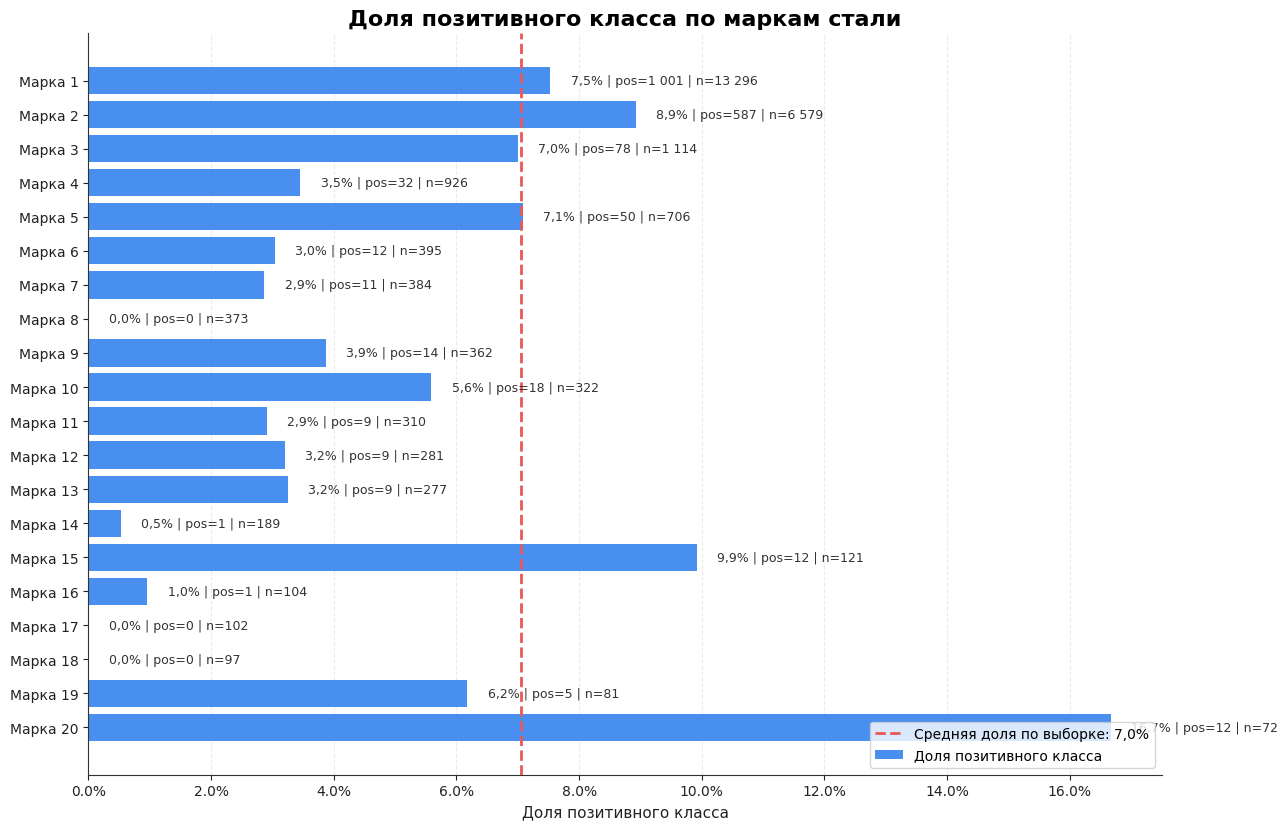

In [11]:
def make_segment_plot_df(df_in, segment_col, anon_prefix, min_count=50, top_n=20):
    if segment_col not in df_in.columns:
        print(f"[SKIP] Нет колонки: {segment_col}")
        return pd.DataFrame()
    
    tmp = pd.DataFrame({
        "segment": clean_str(df_in[segment_col]),
        "target": df_in["target"],
    })
    
    tmp = tmp[
        tmp["segment"].notna()
        & ~tmp["segment"].isin(["", "nan", "None", "<NA>"])
    ].copy()
    
    out = (
        tmp
        .groupby("segment", as_index=False)
        .agg(
            n_rows=("target", "size"),
            positive_count=("target", "sum"),
            positive_rate=("target", "mean"),
        )
    )
    
    out = out[out["n_rows"] >= min_count].copy()
    out = out.sort_values("n_rows", ascending=False).reset_index(drop=True)
    out["anon_name"] = [f"{anon_prefix} {i + 1}" for i in range(len(out))]
    
    return out.head(top_n).copy()

marka_plot = make_segment_plot_df(
    df_work,
    segment_col=STEEL_GRADE_COL,
    anon_prefix="Марка",
    min_count=50,
    top_n=20,
)

print("ДОЛЯ ПОЗИТИВНОГО КЛАССА ПО МАРКАМ СТАЛИ")

if not marka_plot.empty:
    display(marka_plot[["anon_name", "n_rows", "positive_count", "positive_rate"]])
    
    print()
    print("Вывод: дефект распределён неравномерно по маркам стали; часть сегментов имеет риск выше среднего.")
    
    p = marka_plot.iloc[::-1].copy()
    
    fig, ax = plt.subplots(figsize=(13, max(6, len(p) * 0.42)))
    
    bars = ax.barh(
        p["anon_name"],
        p["positive_rate"],
        color=COL_BLUE,
        alpha=0.88,
        label="Доля позитивного класса",
    )
    
    ax.axvline(
        base_rate,
        color=COL_RED,
        linestyle="--",
        linewidth=2,
        label=f"Средняя доля по выборке: {fmt_pct(base_rate)}",
    )
    
    max_rate = max(p["positive_rate"].max(), base_rate)
    
    for bar, rate, n_value, pos_value in zip(
        bars,
        p["positive_rate"],
        p["n_rows"],
        p["positive_count"],
    ):
        ax.text(
            rate + max_rate * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{fmt_pct(rate)} | pos={fmt_int(pos_value)} | n={fmt_int(n_value)}",
            va="center",
            fontsize=9,
            color=COL_DARK,
        )
    
    ax.set_title("Доля позитивного класса по маркам стали")
    ax.set_xlabel("Доля позитивного класса")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    
    ax.legend(loc="lower right")
    prettify(ax, grid_axis="x")
    
    plt.tight_layout()
    plt.show()

ДОЛЯ ПОЗИТИВНОГО КЛАССА ПО ТИПАМ ПРОДУКТА


,anon_name,n_rows,positive_count,positive_rate
0,Продукт 1,54941,19,0.000346
1,Продукт 2,31292,1,0.000032
2,Продукт 3,29447,2318,0.078718
3,Продукт 4,29016,6,0.000207
4,Продукт 5,28079,0,0.000000
5,Продукт 6,12555,9,0.000717
6,Продукт 7,10946,0,0.000000
7,Продукт 8,8633,0,0.000000
8,Продукт 9,8321,0,0.000000
9,Продукт 10,8042,0,0.000000



Средняя доля позитивного класса по исходному df: 1,0%
Вывод: риск дефекта зависит от продуктового сегмента; это нужно учитывать при моделировании.


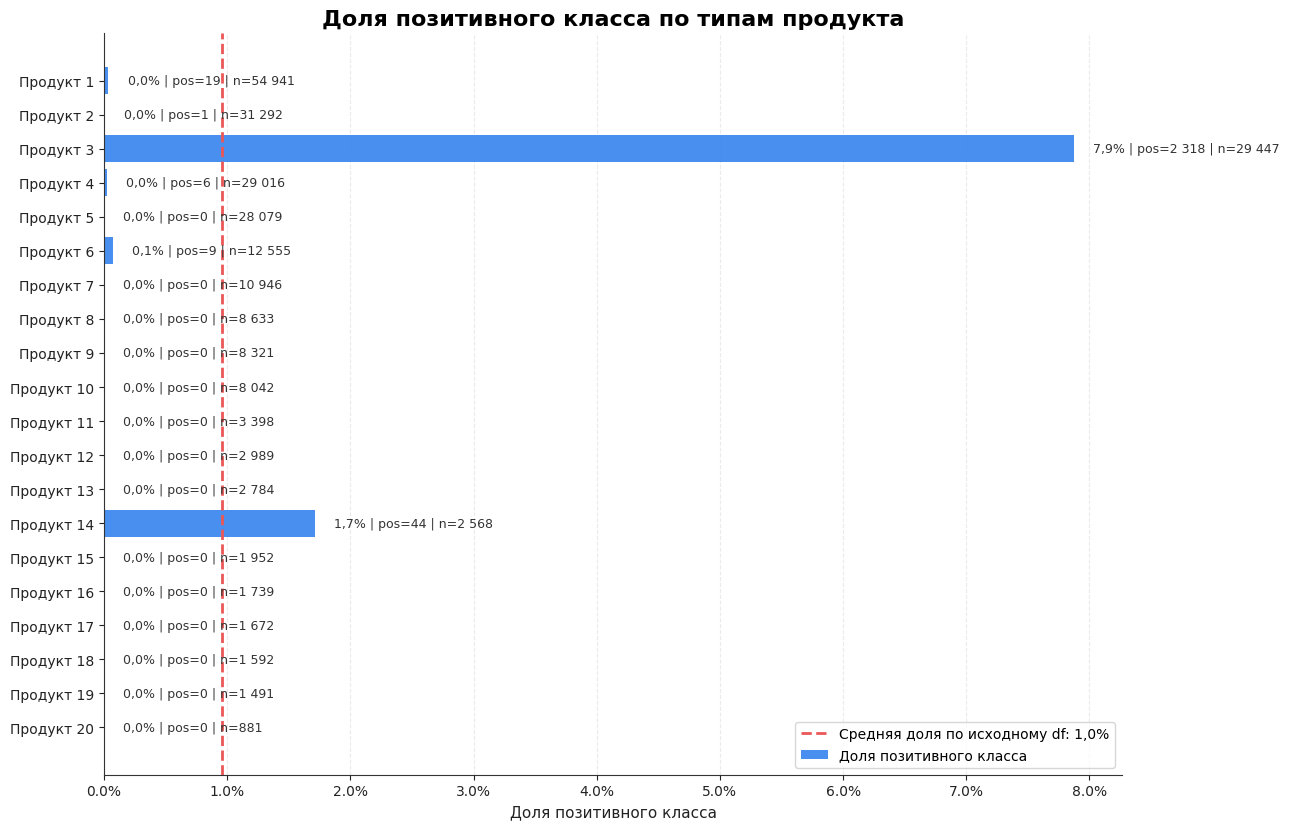

In [12]:
print("ДОЛЯ ПОЗИТИВНОГО КЛАССА ПО ТИПАМ ПРОДУКТА")

if PRODUCT_TYPE_COL not in df.columns:
    print(f"[SKIP] Нет колонки: {PRODUCT_TYPE_COL}")

else:
    y_raw = df[target_col].notna().astype(int)
    base_rate_raw = y_raw.mean()

    tmp = pd.DataFrame({
        "segment": clean_str(df[PRODUCT_TYPE_COL]),
        "target": y_raw,
    })

    tmp = tmp[
        tmp["segment"].notna()
        & ~tmp["segment"].isin(["", "nan", "None", "<NA>"])
    ].copy()

    product_plot = (
        tmp
        .groupby("segment", as_index=False)
        .agg(
            n_rows=("target", "size"),
            positive_count=("target", "sum"),
            positive_rate=("target", "mean"),
        )
    )

    product_plot = product_plot[product_plot["n_rows"] >= 30].copy()

    product_plot = product_plot.sort_values("n_rows", ascending=False).reset_index(drop=True)
    product_plot["anon_name"] = [f"Продукт {i + 1}" for i in range(len(product_plot))]

    product_plot = product_plot.head(20).copy()

    display(product_plot[["anon_name", "n_rows", "positive_count", "positive_rate"]])

    print()
    print(f"Средняя доля позитивного класса по исходному df: {fmt_pct(base_rate_raw)}")
    print("Вывод: риск дефекта зависит от продуктового сегмента; это нужно учитывать при моделировании.")

    p = product_plot.iloc[::-1].copy()

    fig, ax = plt.subplots(figsize=(13, max(6, len(p) * 0.42)))

    bars = ax.barh(
        p["anon_name"],
        p["positive_rate"],
        color=COL_BLUE,
        alpha=0.88,
        label="Доля позитивного класса",
    )

    ax.axvline(
        base_rate_raw,
        color=COL_RED,
        linestyle="--",
        linewidth=2,
        label=f"Средняя доля по исходному df: {fmt_pct(base_rate_raw)}",
    )

    max_rate = max(p["positive_rate"].max(), base_rate_raw)

    for bar, rate, n_value, pos_value in zip(
        bars,
        p["positive_rate"],
        p["n_rows"],
        p["positive_count"],
    ):
        ax.text(
            rate + max_rate * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{fmt_pct(rate)} | pos={fmt_int(pos_value)} | n={fmt_int(n_value)}",
            va="center",
            fontsize=9,
            color=COL_DARK,
        )

    ax.set_title("Доля позитивного класса по типам продукта")
    ax.set_xlabel("Доля позитивного класса")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))

    ax.legend(loc="lower right")
    prettify(ax, grid_axis="x")

    plt.tight_layout()
    plt.show()

In [13]:
top_k_share = 0.10
top_k_units = int(round(len(df_work) * top_k_share))
expected_defects_random_top_k = int(round(pos * top_k_share))

print("BASELINE И ИТОГ")

print(f"Базовая частота дефекта                 : {fmt_pct(base_rate)}")
print(f"Случайный baseline по Precision         : {fmt_pct(base_rate)}")
print(f"All-positive baseline Precision         : {fmt_pct(base_rate)}")
print(f"All-positive baseline Recall            : 100.0%")
print(f"All-negative baseline Recall            : 0.0%")
print(f"Top-10% рискованной продукции           : {fmt_int(top_k_units)} строк")
print(f"Ожидаемо дефектов при случайном top-10% : около {fmt_int(expected_defects_random_top_k)}")
print()
print("ИТОГ:")
print("- Датасет подходит для ML-постановки, но требует строгой очистки признаков.")
print("- Основные проблемы: дисбаланс классов, пропуски, константы, ID/key, возможные leakage/post-fact поля.")
print("- Target формируется как факт наличия записи в карантинной колонке.")
print("- Последние дни требуют проверки зрелости target из-за задержки лабораторного факта.")
print("- Валидацию нужно делать по времени, потому что модель должна прогнозировать будущие производственные дни.")
print("- Accuracy не подходит как главная метрика; нужны Precision, Recall, PR-AUC, Precision@Top-K и Recall@Top-K.")

BASELINE И ИТОГ
Базовая частота дефекта                 : 7,0%
Случайный baseline по Precision         : 7,0%
All-positive baseline Precision         : 7,0%
All-positive baseline Recall            : 100.0%
All-negative baseline Recall            : 0.0%
Top-10% рискованной продукции           : 2 685 строк
Ожидаемо дефектов при случайном top-10% : около 189

ИТОГ:
- Датасет подходит для ML-постановки, но требует строгой очистки признаков.
- Основные проблемы: дисбаланс классов, пропуски, константы, ID/key, возможные leakage/post-fact поля.
- Target формируется как факт наличия записи в карантинной колонке.
- Последние дни требуют проверки зрелости target из-за задержки лабораторного факта.
- Валидацию нужно делать по времени, потому что модель должна прогнозировать будущие производственные дни.
- Accuracy не подходит как главная метрика; нужны Precision, Recall, PR-AUC, Precision@Top-K и Recall@Top-K.
